# Introduction

In the previous notebooks, we studied Gaussian models, Bayesian regression, Gaussian processes, Kalman filtering, and exponential families. Most of these models allowed exact or analytically convenient Bayesian inference.

Here, we move to binary classification with logistic regression. A Gaussian prior over the weights combined with a Bernoulli likelihood produces a non-conjugate posterior, so exact Bayesian inference is no longer available. We will therefore use MAP estimation and the Laplace approximation to construct an approximate posterior and study predictive uncertainty.

# Imports and Setup

In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

warnings.filterwarnings('ignore')
sys.path.append(str(PROJECT_ROOT))

In [2]:
import jax
import jax.numpy as jnp
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from jax import jit, random
from sklearn.datasets import load_iris, make_moons
from tqdm import tqdm

from src.gaussian import Gaussian

KEY = random.key(47)

In [3]:
cmap = matplotlib.colors.LinearSegmentedColormap.from_list(
    "owb", [(255/255, 127/255, 14/255), (1, 1, 1), (31/255, 119/255, 180/255)], N = 1024
)

dw = matplotlib.colors.LinearSegmentedColormap.from_list(
    'wb', [[0.21568627, 0.25490196, 0.29019608], (1, 1, 1)], N = 1024
)

In [4]:
def plot_binary_regression(X, y, w, phi, cmap = cmap, N = 1000, ax = None, xlabel = None, ylabel = None, title = None):
    if ax is None:
        ax = plt.gca()

    x1 = jnp.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, N)
    x2 = jnp.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, N)

    X1, X2 = jnp.meshgrid(x1, x2)
    X_grid = jnp.stack((X1.flatten(), X2.flatten()), axis = 1)

    p = jax.nn.sigmoid(phi(X_grid) @ w).reshape(X1.shape)

    ax.contourf(
        X1, X2,
        p,
        levels = 100,
        cmap = cmap,
        alpha = 0.5,
        vmin = 0,
        vmax = 1,
    )

    ax.scatter(
        X[:, 0], X[:, 1], 
        c = jax.nn.sigmoid(phi(X) @ w), 
        cmap = cmap, 
        s = 30, 
        alpha = 1, 
        edgecolor = [0.21568627, 0.25490196, 0.29019608],
        vmin = 0,
        vmax = 1,
    )

    if xlabel is not None:
        ax.set_xlabel(xlabel)

    if ylabel is not None:
        ax.set_ylabel(ylabel)

    if title is not None:
        ax.set_title(title)

# Binary Logistic Regression

In this notebook we will mostly work on a binary classification problem with
$$ x_i \in \mathbb{R}^{d'}, \quad y_i \in \{ -1, +1 \} $$
As usual, the model will predict the probability of the input belonging to the positive class
$$ \mathbb{P}(y_i = +1 \mid \theta, x_i) $$
using nonlinearity obtained using the feature map
$$ \phi : \mathbb{R}^{d'} \to \mathbb{R}^d $$

## Latent Score and Sigmoid

The model itself firstly will assign some real-valued latent score to the input vector
$$ f(x) = \phi(x)^T w $$
where $w \in \mathbb{R}^d$ is the weight vector of the features.
Note that 
$$ f(x) \in \mathbb{R} $$
To assign the probability of the input belonging to the positive class we will use sigmoid function
$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$
it maps the real-valued input to $(0, 1)$:
$$ \sigma(z): \mathbb{R} \to (0, 1) $$
As can be seen from the definition of the function,
$$ z \to -\infty \Rightarrow \sigma(z) \to 0 $$
$$ z \to +\infty \Rightarrow \sigma(z) \to 1 $$
$$ z = 0 \Rightarrow \sigma(z) = 0.5 $$

Below you can see the graph of the sigmoid function.

Text(0.5, 1.0, 'Sigmoid Function')

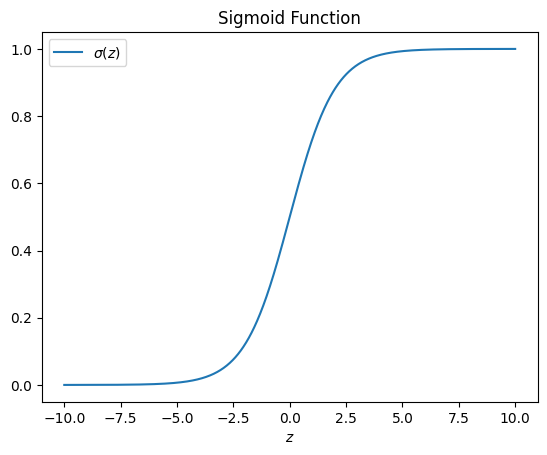

In [5]:
z_plot = jnp.linspace(-10, 10, 1000)
sigma_z = jax.nn.sigmoid(z_plot)

plt.plot(z_plot, sigma_z, label = r"$\sigma(z)$")
plt.legend()
plt.xlabel(r"$z$")
plt.title("Sigmoid Function")

## Bernoulli Likelihood

Since $y_i$ is a target that is either $-1$ or $+1$, the likelihood has a Bernoulli distribution:
$$ \mathbb{P}(y_i = +1 \mid x_i, w) = \sigma(\phi(x_i)^T w) $$
Let us also consider the probability of $x_i$ belonging to the negative class:
$$ \mathbb{P}(y_i = -1 \mid x_i, w) = 1 - \sigma(\phi(x_i)^T w) = \sigma(-\phi(x_i)^T w) $$
Which brings us to a compact form of
$$ p(y \mid x, w) = \sigma(y \phi(x)^T w) $$

## Decision Boundary

The decision on the target has the following form
$$ \hat{y}_i = \begin{cases} -1 & \sigma(f(x_i)) < 0.5 \\ +1 & \sigma(f(x_i)) > 0.5 \end{cases} $$
Or, simpler,
$$ \hat{y}_i = \begin{cases} -1 & f(x_i) < 0 \\ +1 & f(x_i) > 0 \end{cases} $$
Which brings us to the decision boundary of
$$ f(x) = 0 \Rightarrow \phi(x)^T w = 0 $$

Note that the function $f$ is linear in weights but doesnt need to be linear in the original input $x$. That is why we can add some nonlinearity using nonlinear feature map $\phi$.

# Likelihood and Maximum Likelihood

Let us have a dataset with independent observations 
$$ D = \left\{ (x_1, y_1), (x_2, y_2), \dots, (x_n, y_n) \right\} $$
Then, the likelihood
$$ p(y \mid X, w) $$
can be written as
$$ 
\begin{aligned}
p(y \mid X, w) &= \prod_{i=1}^n p(y_i \mid x_i, w) \\
&= \prod_{i=1}^{n} \sigma(y_i f(x_i)) \\
&= \prod_{i=1}^n \sigma(y_i \phi(x_i)^T w)
\end{aligned}
$$

## Log-Likelihood

We have derived the likelihood of
$$ p(y \mid X, w) = \prod_{i=1}^n \sigma(y_i \phi(x_i)^T w) $$
the log-likelihood then can be written as
$$ \ell(w) = \log p(y \mid X, w) = \sum_{i=1}^n \log \sigma(y_i \phi(x_i)^T w) $$
and the maximum likelihood estimation of the model weights is
$$ w_{\text{MLE}} = \arg \max_{w} \ell(w) $$
Logarithm is monotonic, so optimizing likelihood and log-likelihood give same results in $w$, but also we use logarithms because:

* products become sums
* sums are easier to differentiate and optimize
* multiplying many small probabilities can underflow numerically

## Numerically Stable Calculation

During the loss calculation we work with
$$ \log \sigma(z) = -\log \left( 1 + e^{-z} \right) $$
But for large negative values of $z$ it might overflow, so it is more stable to calculate it using
$$ \log \sigma(z) = -\text{softplus} (-z) $$
In JAX it can be done using `logaddexp` function:
$$ \text{logaddexp}(x_1, x_2) = \log \left( \exp(x_1) + \exp(x_2) \right) $$
so the log-sigmoid can be calculated using
$$ \log \sigma(z) = -\text{logaddexp}(0, -z) = -\log \left( \exp(0) + \exp(-z) \right) $$

Maximum likelihood gives a single best estimate of \(w\). In the next section, we instead place a probability distribution over $w$ and formulate logistic regression as a Bayesian model.

# Bayesian Logistic Regression

## Gaussian Prior over Weights

Let our weight be not a vector but a multivariate Gaussian
$$ w \sim \mathcal{N}(m, V) $$
with a density of
$$ p(w) = \frac{1}{(2\pi)^{d/2} |V|^{1/2}} \exp \left( -\frac{1}{2} (w - m)^T V^{-1} (w - m) \right) $$

We are doing so to:
* treat the weight as a distribution
* regularize the model
* encounter uncertainty

## Posterior

Since we already know both likelihood and prior, we can obtain the posterior
$$ p(w \mid X, y) \propto p(y \mid X, w) p(w) $$
Placing the likelihood and prior and taking the logarithm we get the log-posterior
$$
\begin{aligned}
p(w \mid X, y) & \propto p(y \mid X, w) p(w) \\
&= \left( \prod_{i=1}^n \sigma(y_i \phi(x_i)^T w) \right) \left( \frac{1}{(2\pi)^{d/2} |V|^{1/2}} \exp \left( -\frac{1}{2} (w - m)^T V^{-1} (w - m) \right) \right) \\
\log p(w \mid X, y) & \propto \log (p(y \mid X, w) p(w)) \\
&= \sum_{i=1}^n \log \sigma(y_i \phi(x_i)^T w) - \underbrace{ \left( \frac{d}{2} \log (2 \pi) + \frac{1}{2} \log |V| \right)}_{\text{const.}} - \frac{1}{2} (w - m)^T V^{-1} (w - m) \\
&= \sum_{i=1}^n \log \sigma(y_i \phi(x_i)^T w) - \frac{1}{2} (w - m)^T V^{-1} (w - m) + \text{const.}
\end{aligned}
$$

## No Conjugate Posterior

In the previous notebook on [Exponential Families](./6.%20Exponential%20Families.ipynb), we have discussed conjugacy priors for some posteriors. However, there is no conjugacy between Bernoulli likelihood and Gaussian prior. It can be seen in the posterior derivation in the previous section. Also, the sigmoid function makes the posterior nonlinear with respect to $w$. So, the posterior doesnt have a Gaussian form (or, actually, any other proper form). That is why we need to approximate the distribution as Gaussian near the optimal weight $w$.

First, we find the optimal value of $w$ using Maximum a Posteriori:
$$ w_{\text{MAP}} = \arg \max_w \log p(w \mid X, y) $$
again, since logarithm is monotonic, optimizing posterior and log-posterior lead to same results.

Now we can approximate the posterior distribution as a Gaussian with mean $w_{\text{MAP}}$ using **Laplace Approximation**.

# Example: Binary Logistic Regression

Let us have a dataset with nonlinear decision boundary and try to solve the classification problem. We will find an MAP solution for the weights using Gradient Descent.

In [6]:
def log_sigmoid(z): 
    return -jnp.logaddexp(0.0, -z)

def log_likelihood(X, y, w, phi):
    f = phi(X) @ w
    return jnp.sum(log_sigmoid(y * f))

def loss(X, y, w, phi, prior):
    return -(log_likelihood(X, y, w, phi) + prior.log_pdf(w))

## Dataset

Let us use moons dataset. It is a pretty simple example of nonlinearly separated data for a binary classification.

Text(0.5, 1.0, 'Two Moons Dataset')

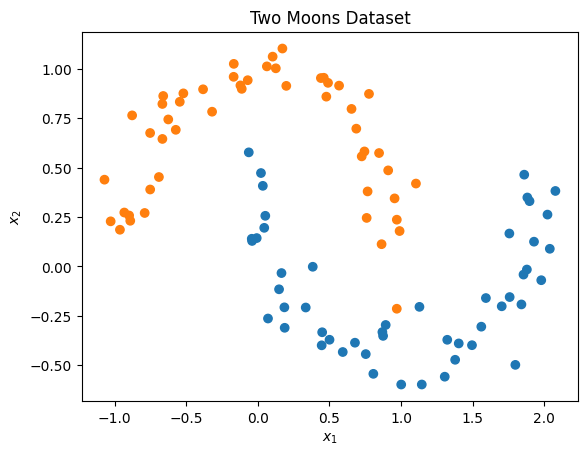

In [7]:
N = 100

X, y = make_moons(n_samples = N, noise = 0.1, random_state = 47)

y_signed = 2 * y - 1    # originally y is 0 or 1, but we want it to be -1 or 1

plt.scatter(X[:, 0], X[:, 1], c = y, cmap = cmap)
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.title("Two Moons Dataset")

## Ordinary Linear Logistic Regression

Let us first try ordinary linear logistic regression with
$$ \phi(x) = \begin{bmatrix} 1 \\ x_1 \\ x_2 \end{bmatrix} $$
so, the likelihood will be in form
$$ \mathbb{P}(y_i = 1 \mid x_i, w) = \sigma(w_0 + x_1 w_1 + x_2 w_2) $$

The Gradient Descent will be run using `jax.value_and_grad` function that returns both value and gradient of the function at a given arguments. We will store the values of the loss function to see the loss curve.

100%|██████████| 10000/10000 [00:00<00:00, 17394.25it/s]


Text(0.5, 1.0, 'Loss Curve')

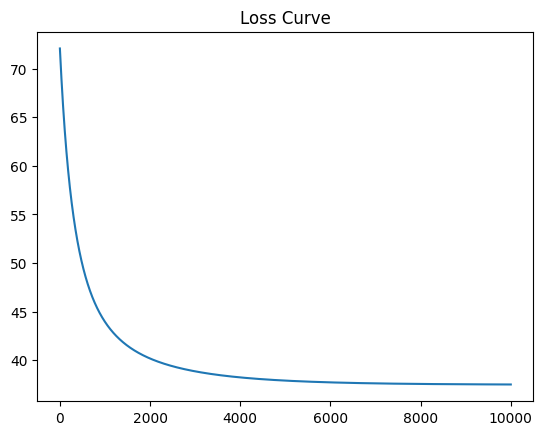

In [8]:
def phi(x):
    return jnp.stack([jnp.ones(x.shape[0]), x[:, 0], x[:, 1]]).T

prior = Gaussian(jnp.zeros(3), jnp.eye(3))
step_size = 1e-4
num_epochs = 10_000

@jit
def update(w):
    L, grad = jax.value_and_grad(loss, argnums = 2)(X, y_signed, w, phi, prior)
    return w - step_size * grad, L

w = jnp.zeros(3)
loss_arr = []

for epoch in tqdm(range(num_epochs)):
    w, L = update(w)
    loss_arr.append(L)

plt.plot(loss_arr)
plt.title("Loss Curve")

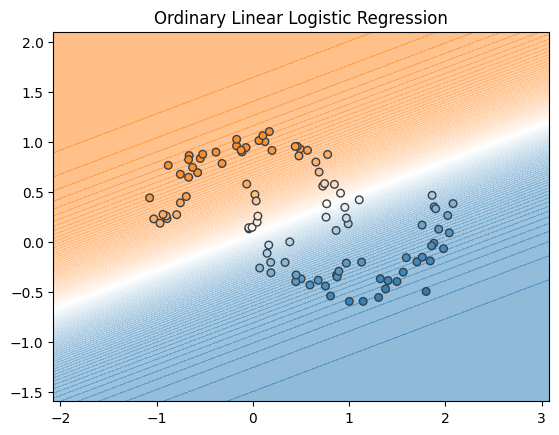

In [9]:
plot_binary_regression(X, y, w, phi = phi, title = "Ordinary Linear Logistic Regression")

Here is what we obtained using ordinary linear logistic regression. As expected, the decision boundary is linear and does not capture the shape of the data.

## RBF Feature Map

What we can do instead is using Radial Basis Function as a feature map. Suppose we generate some points to center the bases around. They will be generated uniformly in the same space as our data. Suppose:
$$ x_i = \begin{bmatrix} x_{i1} \\ x_{i2} \end{bmatrix} $$
with
$$ \begin{cases} x_{\text{min}} \leq x_{i1} \leq x_{\text{max}} \\ y_{\text{min}} \leq x_{i2} \leq y_{\text{max}} \end{cases} \quad \forall i \in I $$
then, the centers will be generated using
$$ c_j = \begin{bmatrix} c_{j1} \\ c_{j2} \end{bmatrix} \sim \begin{bmatrix} U[x_{\text{min}}, x_{\text{max}}] \\ U[y_{\text{min}}, y_{\text{max}}] \end{bmatrix} $$
So, for 
$$x \in \mathbb{R}^{d'}, c \in \mathbb{R}^{d \times d'} $$
the feature map is
$$ \phi(x) = \begin{bmatrix} \exp \left( - \frac{\| x - c_1 \|_2^2}{2 \ell^2} \right) \\ \vdots \\ \exp \left( - \frac{\| x - c_d \|_2^2}{2 \ell^2} \right) \end{bmatrix} $$
so that 
$$ \phi: \mathbb{R}^{d'} \to \mathbb{R}^d $$

In [10]:
KEY, rbf_key = random.split(KEY, 2)

x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()
center = 0.5 * jnp.array([x_max + x_min, y_max + y_min])
scale = jnp.array([x_max - x_min, y_max - y_min])

n_features = 20

centers = (jax.random.uniform(rbf_key, shape = (n_features, 2)) - 0.5) * scale + center    # U[0, 1] -> U[min, max]

def rbf_phi(x, ell = 0.2):
    return jnp.exp(-0.5 * jnp.sum((x[:, None, :] - centers[None, :, :])**2 / ell**2, axis = -1))

Text(0.5, 1.0, 'RBF Centers Visualization')

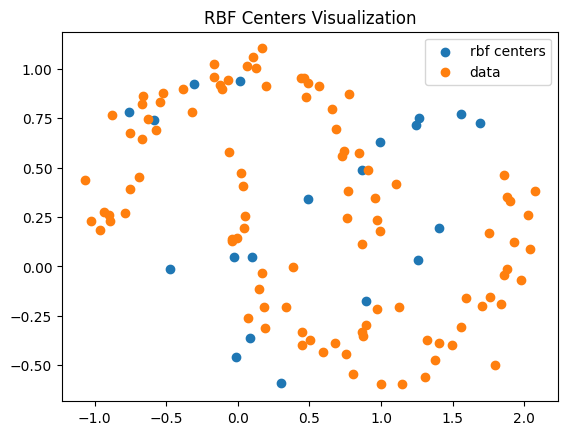

In [11]:
plt.scatter(centers[:, 0], centers[:, 1], label = "rbf centers")
plt.scatter(X[:, 0], X[:, 1], label = "data")
plt.legend()
plt.title("RBF Centers Visualization")

Now we train the estimator as before

100%|██████████| 10000/10000 [00:00<00:00, 11843.10it/s]


Text(0.5, 1.0, 'Loss Curve')

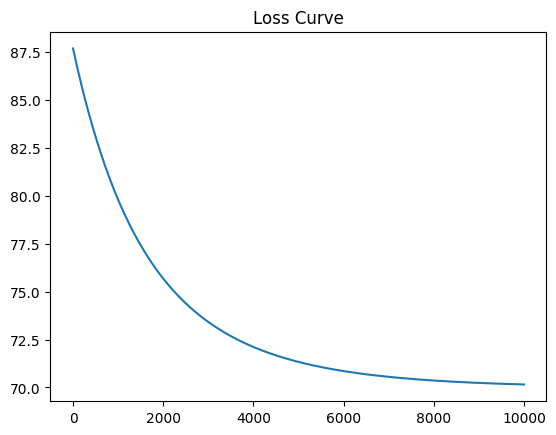

In [12]:
prior = Gaussian(jnp.zeros(n_features), jnp.eye(n_features))
step_size = 1e-4
num_epochs = 10_000

@jit
def update(w):
    L, grad = jax.value_and_grad(loss, argnums = 2)(X, y_signed, w, rbf_phi, prior)
    return w - step_size * grad, L

w = jnp.zeros(n_features)
loss_arr = []

for epoch in tqdm(range(num_epochs)):
    w, L = update(w)
    loss_arr.append(L)

plt.plot(loss_arr)
plt.title("Loss Curve")

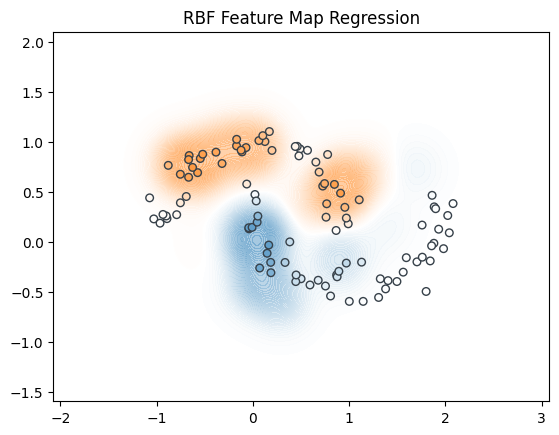

In [13]:
plot_binary_regression(X, y, w, phi = rbf_phi, title = "RBF Feature Map Regression")

This time the regression better captures the general shape of data. However, as can be seen, in the right end of the orange class, regression does not capture the data. This is due to the fact that there is no RBF center at that place. It can be seen on the RBF centers visualization plot above. To tackle this problem, more samples can be generated, however one should be aware that it increases the dimensionality of the problem. Let us try 100 RBF centers (features) instead of 20.

Text(0.5, 1.0, 'RBF Centers Visualization')

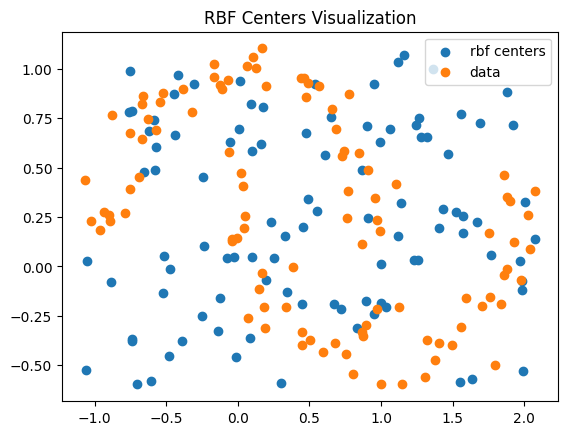

In [14]:
n_features = 100

centers = (jax.random.uniform(rbf_key, shape = (n_features, 2)) - 0.5) * scale + center    # U[0, 1] -> U[min, max]

plt.scatter(centers[:, 0], centers[:, 1], label = "rbf centers")
plt.scatter(X[:, 0], X[:, 1], label = "data")
plt.legend()
plt.title("RBF Centers Visualization")

Now the samples seem to be better distributed through the data space. Let us try to train the model again.

100%|██████████| 10000/10000 [00:02<00:00, 4195.97it/s]


Text(0.5, 1.0, 'Loss Curve')

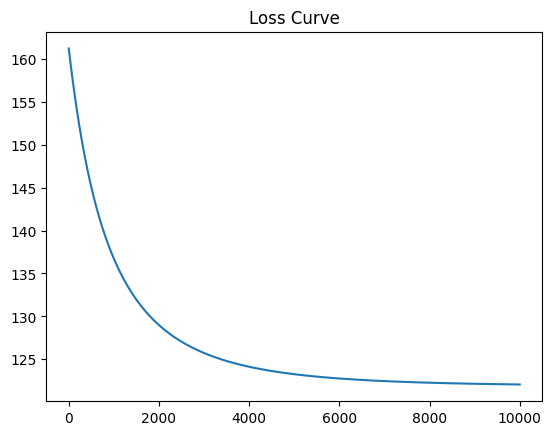

In [15]:
prior = Gaussian(jnp.zeros(n_features), jnp.eye(n_features))
step_size = 1e-4
num_epochs = 10_000

w = jnp.zeros(n_features)
loss_arr = []

for epoch in tqdm(range(num_epochs)):
    w, L = update(w)
    loss_arr.append(L)

plt.plot(loss_arr)
plt.title("Loss Curve")

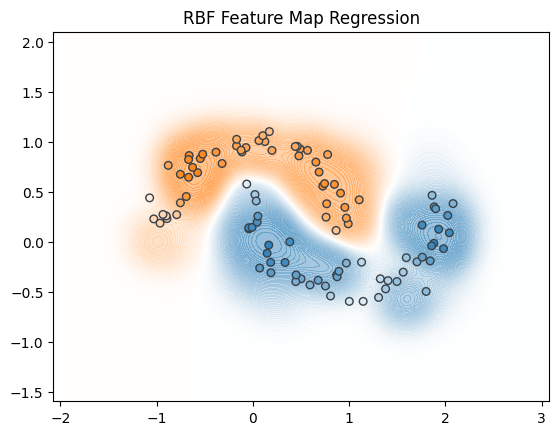

In [16]:
plot_binary_regression(X, y, w, phi = rbf_phi, title = "RBF Feature Map Regression")

As can be seen, now that right end is better captured.

# Newton's Method

As we saw in the last section, Gradient Descent took thousands of iterations to find the optimal $w_{\text{MAP}}$. Let us try another way. We can use Newton's method to find the $w_{\text{MAP}}$. Let us use the following forms of the familiar expressions in this section:
$$ \Phi = \begin{bmatrix} \phi(x_1)^T \\ \phi(x_2)^T \\ \vdots \\ \phi(x_n)^T \end{bmatrix},\quad f = \Phi w,\quad \pi_i = \sigma(y_i f_i) $$

## Gradient

For the Newton's method we will need a gradient and a Hessian of the objective function (which is our log-posterior):
$$ \log p(w \mid X, y) = \sum_{i=1}^n \log \sigma(y_i \phi(x_i)^T w) - \frac{1}{2} (w - m)^T V^{-1} (w - m) + C $$

Let us differentiate it with respect to $w$:
$$
\begin{aligned}
\frac{d}{dz} \log\sigma(z) &= 1 - \sigma(z) \\
g(w) &= \nabla_{w} \log p(w \mid X, y) \\
&= \sum_{i=1}^n \nabla_w \log \sigma(y_i \phi(x_i)^T w) - V^{-1} (w - m) \\
&= \sum_{i=1}^n (1 - \sigma (y_i \phi(x_i)^T w)) \nabla_w (y_i \phi(x_i)^T w) - V^{-1} (w - m) \\
&= \sum_{i=1}^n (1 - \underbrace{\sigma (y_i \phi(x_i)^T w)}_{\pi_i}) y_i \phi(x_i) - V^{-1} (w - m) \\
&= \Phi^T (y \odot (1 - \pi)) - V^{-1} (w - m)
\end{aligned}
$$

Where $\odot$ is Hadamard product:
$$ \begin{bmatrix} a_1 \\ a_2 \\ \vdots \\ a_n \end{bmatrix} \odot \begin{bmatrix} b_1 \\ b_2 \\ \vdots \\ b_n \end{bmatrix} = \begin{bmatrix} a_1 b_1 \\ a_2 b_2 \\ \vdots \\ a_n b_n \end{bmatrix} $$

Conceptually in the gradient above two thigs are happening at the same time:
* likelihood part is changing the entries of $w$ to match the predictions to the targets
* prior part is changing them to match the mean of the prior

So, very similar to a regularization.

## Hessian

We will also need a Hessian of the log-posterior in the Newton's method
$$ H(w) = \nabla_w \nabla_w \log p(w \mid X, y) $$

The prior term's gradient is just
$$ \nabla_w \nabla_w \frac{1}{2} (w - m)^T V^{-1} (w - m) = V^{-1} $$

Now likelihood term. We already know that
$$ \nabla_w \log p(y \mid X, w) = \Phi^T (y \odot (1 - \pi)) $$
where only $\pi$ depends on $w$. For simplicity, let us consider an element indexed $i$
$$
\begin{aligned}
(\nabla_w \nabla_w \log p(y \mid X, w))_i &= \nabla_w (y_i (1 - \pi_i) \phi(x_i)) \\
&= - y_i \phi(x_i) (\nabla_w \pi_i)^T
\end{aligned}
$$

Since the derivative of sigmoid is
$$ \sigma'(z) = \sigma(z) (1 - \sigma(z)) $$

The derivative of $pi_i$ is
$$ \nabla_w \pi_i = \pi_i (1 - \pi_i) \nabla_w z_i = \pi_i (1 - \pi_i) y_i \phi(x_i) $$

Plugging back we obtain
$$
\begin{aligned}
(\nabla_w \nabla_w \log p(y \mid X, w))_i &= - y_i \phi(x_i) (\nabla_w \pi_i)^T \\
&= -y_i \phi(x_i) [\pi_i (1 - \pi_i) y_i \phi(x_i)]^T \\
&= -\pi_i (1 - \pi_i) \phi(x_i) \phi(x_i)^T
\end{aligned}
$$

The last equation is due to $y_i^2 = 1$.

Now summing up all observations we get
$$ \nabla_w^2 \log p(y \mid X, w) = -\sum_{i=1}^n \pi_i (1 - \pi_i) \phi(x_i) \phi(x_i)^T $$

Here we can define 
$$ R = \text{diag}(\pi_i (1 - \pi_i)) $$

Then, the Hessian is
$$ H(w) = -\Phi^T R \Phi - V^{-1} = -(\Phi^T R \Phi + V^{-1}) $$

Note that the Hessian is negative semi-definite, so log-posterior is concave.

## Newton Update

Now let us write the Newton update for our log-posterior:
$$ w_{k+1} = w_k - H^{-1}(w_k) g(w_k) $$

For numerical stability we will not directly calculate the inverse of $H(w_k)$ but use the solution of a matrix equation
$$ H(w_k) \Delta w_k = g(w_k) \Rightarrow \Delta w_k = H^{-1}(w_k) g(w_k) $$

So the update becomes
$$ w_{k+1} = w_k - \Delta w_k $$

Let us run a short experiment with the same prior distribution.

In [17]:
n_features = 100
centers = (jax.random.uniform(rbf_key, shape = (n_features, 2)) - 0.5) * scale + center

m = jnp.zeros(n_features)
V = jnp.eye(n_features)

w = jnp.zeros(n_features)
delta_norm = float("inf")

needed_iterations = 0

while delta_norm > 1e-3:
    Phi = rbf_phi(X)
    f = Phi @ w
    pi = jax.nn.sigmoid(y_signed * f)
    r = pi * (1 - pi)

    g = Phi.T @ (y_signed * (1 - pi)) - jax.scipy.linalg.solve(V, w - m)
    H = - Phi.T @ (r[:, None] * Phi) - jax.scipy.linalg.inv(V)

    delta = jax.scipy.linalg.solve(H, g)
    delta_norm = jnp.linalg.norm(delta)

    w = w - delta

    needed_iterations += 1

print(f"converged in {needed_iterations} iterations")

converged in 5 iterations


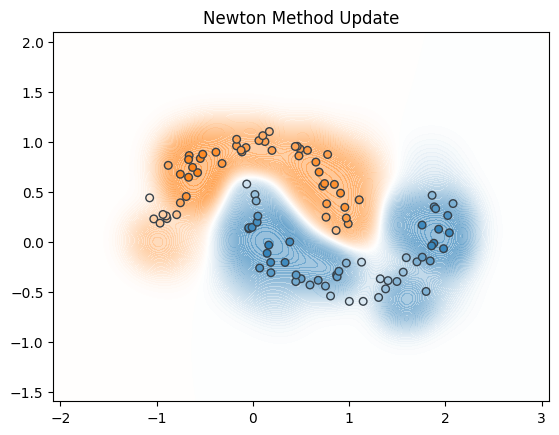

In [18]:
plot_binary_regression(X, y, w, rbf_phi, title = "Newton Method Update")

# Laplace Approximation

Since we cant directly calculate the posterior mean and variance (since the distribution is not a well-known one), we can approximate the distribution around the $w_{\text{MAP}}$ we have obtained in the previous section.

## Second-Order Expansion

The posterior $p(w \mid X, y)$ is not Gaussian, but we know its mode and can approximate the distribution as Gaussian around it. Using Taylor expansion we know
$$ \log p(w \mid X, y) \approx \log p(w_{\text{MAP}} \mid X, y) + g (w - w_{\text{MAP}}) + \frac{1}{2} (w - w_{\text{MAP}})^T H (w - w_{\text{MAP}}) $$
where
* $g = \nabla \log p(w \mid X, y) \mid _{w = w_{\text{MAP}}}$
* $H = \nabla^2 \log p(w \mid X, y) \mid _{w = w_{\text{MAP}}}$

Since at $w = w_{\text{MAP}}$ we obtain the mode of the distribution, 
$$ g = 0 $$

So we are left with
$$ \log p(w \mid X, y) \approx \log p(w_{\text{MAP}} \mid X, y) + \frac{1}{2} (w - w_{\text{MAP}})^T H (w - w_{\text{MAP}}) $$

This finding suggest us that we can locally approximate the log-posterior with a quadratic function. And since the exponent of the quadratic function has a Gaussian shape, we can approximate our posterior with a Gaussian distribution.

## Gaussian Approximation

We have a form of
$$ \log p(w \mid X, y) \approx \log p(w_{\text{MAP}} \mid X, y) + \frac{1}{2} (w - w_{\text{MAP}})^T H (w - w_{\text{MAP}}) $$
exponentiating both sides we get
$$ p(w \mid X, y) \approx p(w_{\text{map}} \mid X, y) \exp \left( \frac{1}{2} (w - w_{\text{MAP}})^T H (w - w_{\text{MAP}}) \right) $$
which suggest us that
$$ p(w \mid X, y) \propto \mathcal{N}(w; w_{\text{MAP}}, -H^{-1}) $$

So we obtained a Gaussian approximation of our posterior. The Gaussian has the parameters:
* mean of MAP estimation
* covariance of inverse local curvature

## Posterior Weight Samples

Now, when we can approximate the posterior as a Gaussian, let us sample a few weight vectors
$$ w^{(s)} \sim \mathcal{N}(w_{\text{MAP}}, -H^{-1}) $$
and see the probability of being a positive class for a new point $x_*$
$$ \mathbb{P} (y_* = 1 \mid x_*, w^{(s)}) = \sigma(\phi(x_*)^T w^{(s)}) $$

Text(0.5, 1.0, 'Sampled Weight Distributions vs MAP')

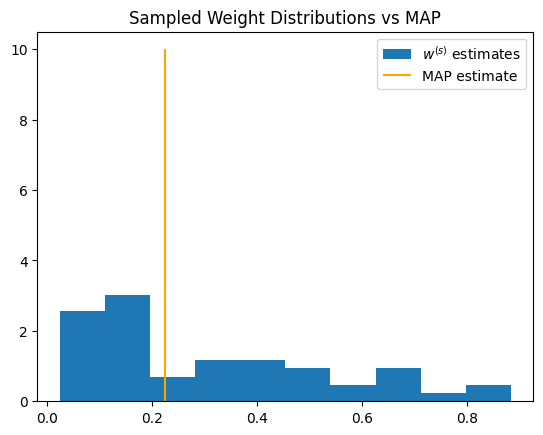

In [19]:
KEY, weight_key, x_key = random.split(KEY, 3)

posterior = Gaussian(w, -jax.scipy.linalg.inv(H))
weight_samples = posterior.sample(sample_size = 50, key = weight_key)

x_new = random.normal(x_key, shape = (1, 2))
logits = (rbf_phi(x_new) @ weight_samples.T).squeeze()
probs = jax.nn.sigmoid(logits)

map_logit = rbf_phi(x_new) @ w
map_prob = jax.nn.sigmoid(map_logit)

plt.hist(probs, density = True, label = r"$w^{(s)}$ estimates")
plt.vlines(map_prob, 0, 10, colors = "orange", label = "MAP estimate")
plt.legend()
plt.title("Sampled Weight Distributions vs MAP")

We have sampled 50 weight vectors from an approximated posterior and calculated the probability using each one of them. The probability obtained by the MAP estimate of the weight is also present as an orange line. The purpose of the plot was to show that MAP gives only one estimate, while the Bayesian logistic regression gives a full distribution over the weight vectors.

## Decision Boundaries

Now let us use the sampled weight vectors from the previous subsection and draw each one's decision boundary for the regression.

Text(0.5, 1.0, 'Decision Boundaries for Sampled Weight Vectors')

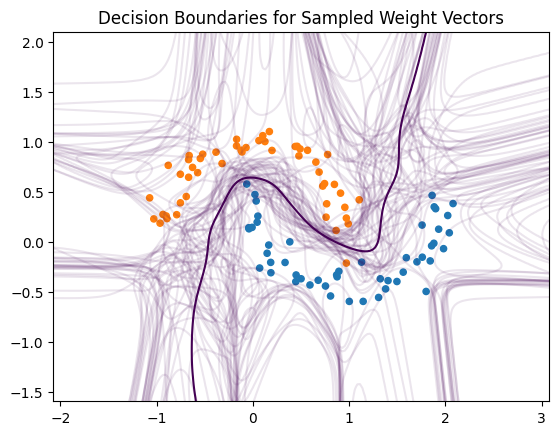

In [20]:
x1 = jnp.linspace(x_min - 1, x_max + 1, 200)
x2 = jnp.linspace(y_min - 1, y_max + 1, 200)

X1, X2 = jnp.meshgrid(x1, x2)
X_grid = jnp.stack([X1.ravel(), X2.ravel()], axis=1)

Phi_grid = rbf_phi(X_grid)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap=cmap,
    s=20
)

for w_sample in weight_samples:
    f = Phi_grid @ w_sample
    F = f.reshape(X1.shape)

    plt.contour(
        X1,
        X2,
        F,
        levels=[0],     # plotting level-0 of the logits (decision boundary)
        alpha=0.1
    )

f = Phi_grid @ w
F = f.reshape(X1.shape)

plt.contour(
    X1,
    X2,
    F,
    levels=[0],
    alpha=1
)

plt.title("Decision Boundaries for Sampled Weight Vectors")

The graph above shows the decision boundary of sampled weight vectors as well as the MAP decision boundary (the darker one).

There is a seenable cluster of the decision boundaries between two classes. That means that the weight vectors "agree" that in the middle of the space there is an S-shaped region where the estimator gives a zero-logit.

In this example we can clearly see that the MAP probability does not correspond to the posterior uncertainty. Sometimes people interpret the MAP probability as the model's uncertainty:
* $\mathbb{P}(y_* = +1 \mid x_*, X, y) \approx 0$ as "certainly negative class"
* $\mathbb{P}(y_* = +1 \mid x_*, X, y) \approx 1$ as "certainly positive class"
* $\mathbb{P}(y_* = +1 \mid x_*, X, y) \approx 0.5$ as "not certain"

However, the MAP probability comes from only one probability surface, while the true uncertainty comes from variation on such models.

# Posterior Predictive Distribution

## Predictive Integral

Under Laplace approximation, we obtained that 
$$ p(w \mid X, y) \sim \mathcal{N}(w_{\text{MAP}}, -H^{-1}) $$
For a new point $x_*$, the predictive distribution is, then
$$ \mathbb{P}(y_* = +1 \mid x_*, D) \approx \int \sigma(\phi(x_*)^T w) p(w \mid D) dw $$
Since $w$ is Gaussian and $\phi(x_*)^T w$ is linear in $w$, 
$$ f_* = \phi(x_*)^T w \sim \mathcal{N}(\mu_*, s_*^2) $$
where
$$ \mu_* = \phi(x_*)^T w_{\text{MAP}}, \quad s_*^2 = \phi(x_*)^T (- H^{-1}) \phi(x_*) $$
So, we can reduce the prediction to one univariate Gaussian integral:
$$ \mathbb{P}(y_* = +1 \mid x_*, D) = \int \sigma(f_*) p(f_*) df_* $$

The thing is that $\sigma(f_*)$ adds nonlinearity to the integral, thus, we do not have any close form solution for the integral.

## Monte Carlo Estimation

The solution is to ues Monte Carlo estimation to approximate the integral. For an arbitrary distribution $\mathcal{D}$ we can estimate the integral using samples from the distribution. Let us sample $N$ times from $\mathcal{D}$, then
$$ \int f(x) p(x) dx \approx \frac{1}{N} \sum_{i=1}^N f(x^{(s)}) $$
where $x^{(s)}$ are the samples from $\mathcal{D}$.

## Predictive Probability

Now let us use the Monte Carlo estimation to calculate the predictive probability.

Text(0.5, 1.0, 'Predictive Distribution')

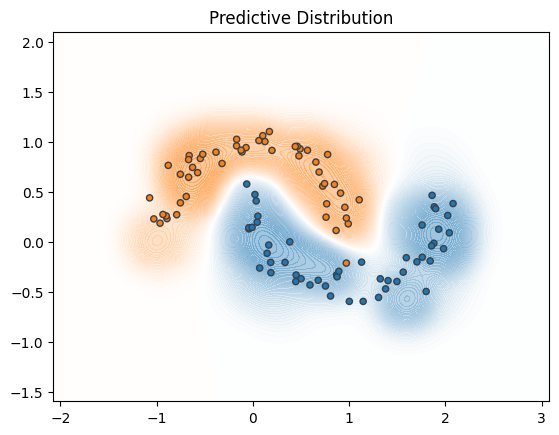

In [21]:
KEY, normal_key = random.split(KEY, 2)
n_samples = 10_000

normal_samples = random.normal(normal_key, (n_samples, ))

Phi = rbf_phi(X_grid)
means = Phi @ w
stds = jnp.sqrt(Phi @ (-jax.scipy.linalg.inv(H)) @ Phi.T).diagonal()

predictive_samples = means + normal_samples[:, None] * stds     # mu + N(0, 1) * std = N(mu, std^2)
prob_samples = jax.nn.sigmoid(predictive_samples)               # passing the samples through sigmoid
prob = prob_samples.mean(axis = 0)                              # averaging to obtain the predictive integral

plt.contourf(
    X1, X2,
    prob.reshape(X1.shape),
    levels = 100,
    cmap = cmap,
    alpha = 0.5,
    vmin = 0,
    vmax = 1,
)

plt.scatter(X[:, 0], X[:, 1], 
            c = y, 
            cmap = cmap,
            s = 20,
            edgecolor = [0.21568627, 0.25490196, 0.29019608])

plt.title("Predictive Distribution")

Note that the graph above is not the same as the graph of
$$ \sigma(\phi(x)^T w_{\text{MAP}}) $$
since in general
$$ \mathbb{E} [\sigma(X)] \neq \sigma (\mathbb{E}[X]) $$

## Epistemic Uncertainty

Now let us examine the epistemic uncertainty of our predictor, i.e.
$$ \text{Var}_{w} (\sigma (\phi(x_*)^T w)) $$

Since we already have 
$$ \sigma(\phi(x)^T w^{(s)}) $$
we can compute its variance directly.

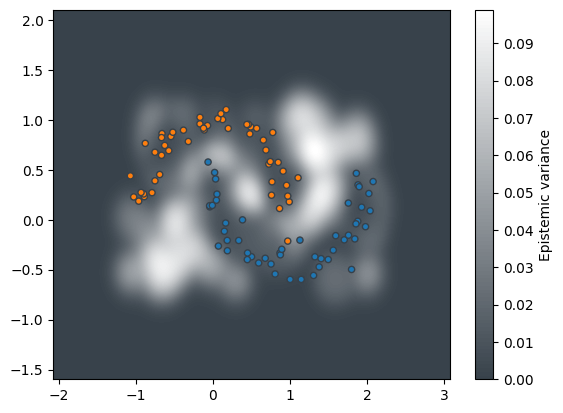

In [22]:
epistemic_var = prob_samples.var(axis=0)

contour = plt.contourf(
    X1, X2,
    epistemic_var.reshape(X1.shape),
    levels = 100,
    cmap = dw,
    alpha = 1,
    vmin = epistemic_var.min(),
    vmax = epistemic_var.max(),
)

plt.scatter(
    X[:, 0], X[:, 1],
    c = y,
    cmap = cmap,
    s = 20,
    edgecolor = [0.21568627, 0.25490196, 0.29019608],
)

plt.colorbar(contour, label = "Epistemic variance")

In this plot the uncertainty on the decision bound is seenable very well. Away from the data, the model's uncertainty is almost zero. It shows that the model is pretty certain in its prediction of
$$ \mathbb{P}(y = +1 \mid x, D) = 0.5 $$

# Experiments

Now let us experiment with the parameters of our model.

In [23]:
def run_laplace_experiment(
    X,
    y,
    phi,
    m,
    V,
    X_grid,
    normal_samples,
    tol=1e-3,
):
    y_signed = 2 * y - 1

    Phi_data = phi(X)
    w = jnp.zeros_like(m)

    delta_norm = jnp.inf
    n_iter = 0

    # Newton optimization
    while delta_norm > tol:
        f = Phi_data @ w
        pi = jax.nn.sigmoid(y_signed * f)
        r = pi * (1 - pi)

        g = (
            Phi_data.T @ (y_signed * (1 - pi))
            - jax.scipy.linalg.solve(V, w - m)
        )

        H = (
            -Phi_data.T @ (r[:, None] * Phi_data)
            - jax.scipy.linalg.inv(V)
        )

        delta = jax.scipy.linalg.solve(H, g)

        w = w - delta
        delta_norm = jnp.linalg.norm(delta)

        n_iter += 1

    # Recompute Hessian at final MAP estimate
    f = Phi_data @ w
    pi = jax.nn.sigmoid(y_signed * f)
    r = pi * (1 - pi)

    H = (
        -Phi_data.T @ (r[:, None] * Phi_data)
        - jax.scipy.linalg.inv(V)
    )

    Sigma = -jax.scipy.linalg.inv(H)

    # Predictive distribution on grid
    Phi_grid = phi(X_grid)

    mean_grid = Phi_grid @ w
    var_grid = jnp.sum((Phi_grid @ Sigma) * Phi_grid, axis=1)
    std_grid = jnp.sqrt(var_grid)

    predictive_samples = (
        mean_grid[None, :]
        + normal_samples[:, None] * std_grid[None, :]
    )

    prob_samples = jax.nn.sigmoid(predictive_samples)

    prob = prob_samples.mean(axis=0)
    epistemic_var = prob_samples.var(axis=0)

    # Predictive distribution at training points
    mean_data = Phi_data @ w
    var_data = jnp.sum((Phi_data @ Sigma) * Phi_data, axis=1)
    std_data = jnp.sqrt(var_data)

    predictive_samples_data = (
        mean_data[None, :]
        + normal_samples[:, None] * std_data[None, :]
    )

    prob_samples_data = jax.nn.sigmoid(predictive_samples_data)

    prob_data = prob_samples_data.mean(axis=0)
    epistemic_var_data = prob_samples_data.var(axis=0)

    return {
        "w": w,
        "Sigma": Sigma,
        "prob": prob,
        "prob_data": prob_data,
        "epistemic_var": epistemic_var,
        "epistemic_var_data": epistemic_var_data,
        "n_iter": n_iter,
    }

## Prior Strength

In the experiment above we have used
$$ w \sim \mathcal{N}(0, I) $$
Now let us experiment with the covariance matrix.

In [24]:
V_experiment = {}
V_grid = [0.1, 0.5, 1, 2]

m = jnp.zeros(n_features)

for V_sigma in V_grid:
    V = V_sigma**2 * jnp.eye(n_features)
    V_experiment[V_sigma] = run_laplace_experiment(X, y, rbf_phi, m, V, X_grid, normal_samples)
    print(f"V_sigma={V_sigma}\tconverged in {V_experiment[V_sigma]['n_iter']} iterations")

V_sigma=0.1	converged in 2 iterations
V_sigma=0.5	converged in 4 iterations
V_sigma=1	converged in 5 iterations
V_sigma=2	converged in 6 iterations


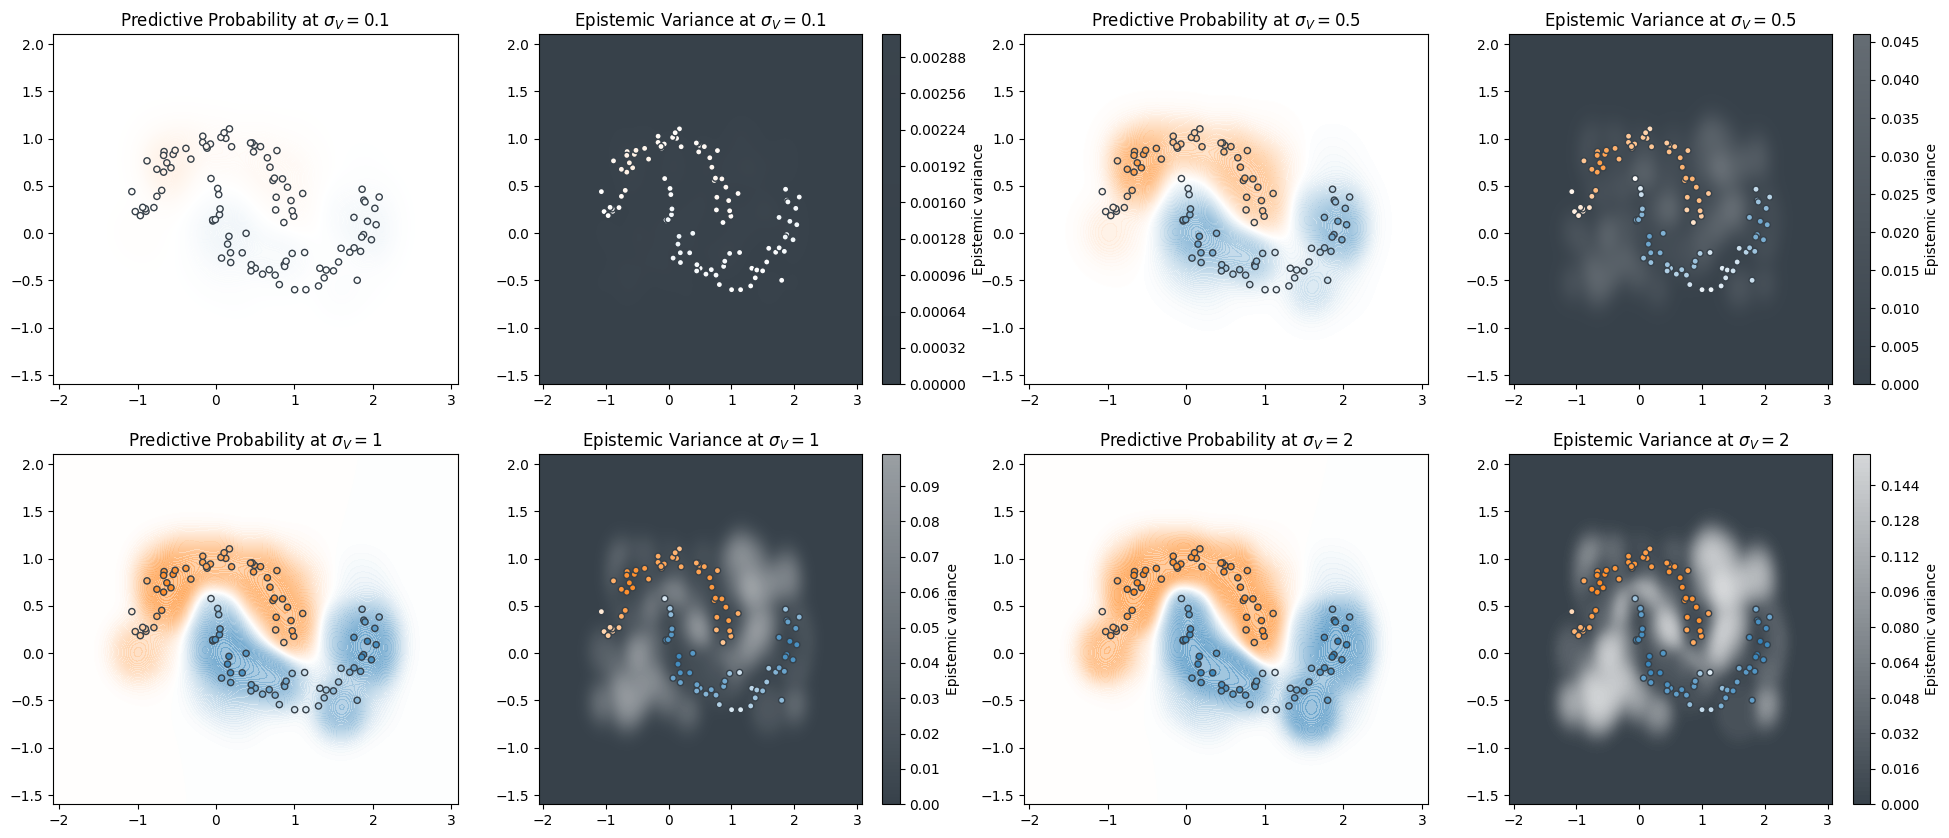

In [25]:
fig, axes = plt.subplots(nrows = 2, ncols = 4, figsize = (24, 10))
ax = axes.flatten()

for i, V_sigma in enumerate(V_grid):
    prob = V_experiment[V_sigma]["prob"]
    prob_data = V_experiment[V_sigma]["prob_data"]
    epistemic_var = V_experiment[V_sigma]["epistemic_var"]
    epistemic_var_data = V_experiment[V_sigma]["epistemic_var_data"]

    ax[2*i].contourf(
        X1, X2,
        prob.reshape(X1.shape),
        levels = 100,
        cmap = cmap,
        alpha = 0.5,
        vmin = 0,
        vmax = 1,
    )

    ax[2*i].scatter(
        X[:, 0], X[:, 1], 
        c = prob_data, 
        cmap = cmap,
        s = 20,
        edgecolor = [0.21568627, 0.25490196, 0.29019608],
        vmin = 0,
        vmax = 1,
    )

    contour = ax[2*i+1].contourf(
        X1, X2,
        epistemic_var.reshape(X1.shape),
        levels = 100,
        cmap = dw,
        alpha = 1,
        vmin = 0,
        vmax = 0.2,
    )

    ax[2*i+1].scatter(
        X[:, 0], X[:, 1], 
        c = prob_data,
        s = 20,
        edgecolor = [0.21568627, 0.25490196, 0.29019608],
        cmap = cmap,
        alpha = 1,
        vmin = 0,
        vmax = 1,
    )

    fig.colorbar(contour, label = "Epistemic variance")

    ax[2*i].set_title(rf"Predictive Probability at $\sigma_V={V_sigma}$")
    ax[2*i+1].set_title(rf"Epistemic Variance at $\sigma_V={V_sigma}$")

As the prior variance increases, the posterior predictive becomes more flexible and the epistemic variance grows, especially away from densely observed regions. With a strong prior, predictions are heavily regularized and posterior samples agree closely; with a weaker prior, the model fits the two-moons structure better but becomes less certain about the decision function in poorly constrained parts of the input space.

## Amount of Training Data

Now let us experiment with the amount of training data and prior
$$ w \sim \mathcal{N}(0, I) $$

In [26]:
data_experiment = {}
N_grid = [20, 50, 100, 200]

m = jnp.zeros(n_features)
V = jnp.eye(n_features)

datasets = []
for N in N_grid:
    Xi, yi = make_moons(n_samples = N, noise = 0.1, random_state = 47)
    datasets.append((Xi, yi))

for i, N in enumerate(N_grid):
    Xi, yi = datasets[i]
    
    data_experiment[N] = run_laplace_experiment(Xi, yi, rbf_phi, m, V, X_grid, normal_samples)
    print(f"N={N}\tconverged in {data_experiment[N]['n_iter']} iterations")

N=20	converged in 4 iterations
N=50	converged in 4 iterations
N=100	converged in 5 iterations
N=200	converged in 6 iterations


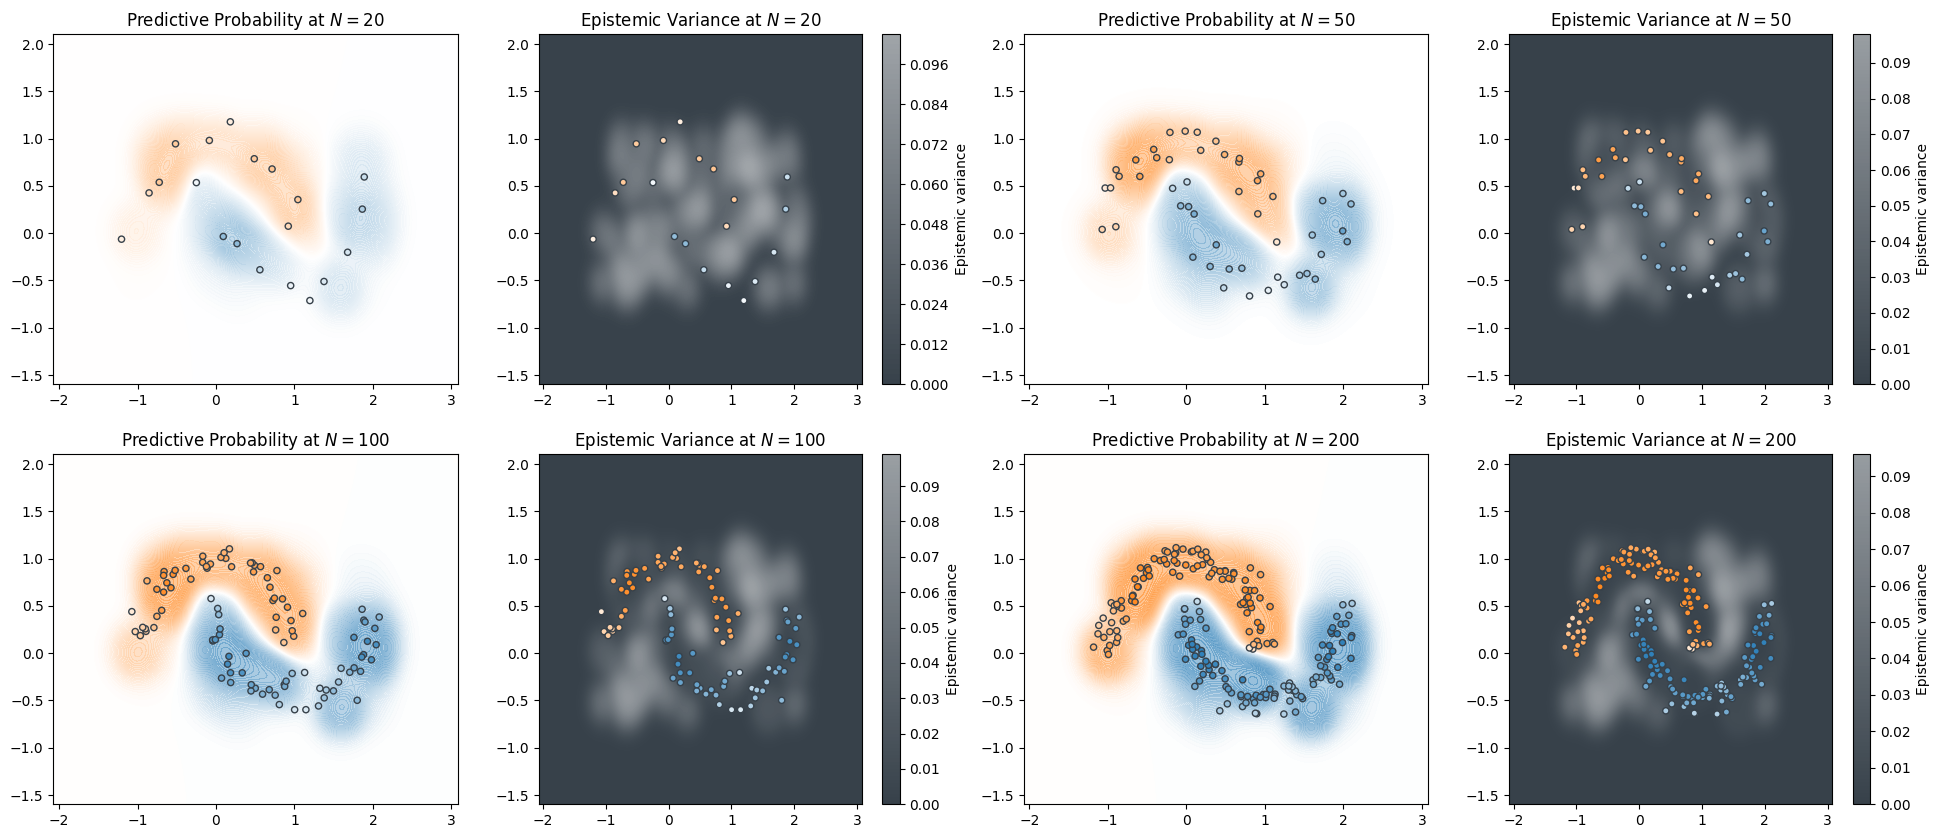

In [27]:
fig, axes = plt.subplots(nrows = 2, ncols = 4, figsize = (24, 10))
ax = axes.flatten()

for i, N in enumerate(N_grid):
    prob = data_experiment[N]["prob"]
    prob_data = data_experiment[N]["prob_data"]
    epistemic_var = data_experiment[N]["epistemic_var"]
    epistemic_var_data = data_experiment[N]["epistemic_var_data"]

    Xi, yi = datasets[i]

    ax[2*i].contourf(
        X1, X2,
        prob.reshape(X1.shape),
        levels = 100,
        cmap = cmap,
        alpha = 0.5,
        vmin = 0,
        vmax = 1,
    )

    ax[2*i].scatter(
        Xi[:, 0], Xi[:, 1], 
        c = prob_data, 
        cmap = cmap,
        s = 20,
        edgecolor = [0.21568627, 0.25490196, 0.29019608],
        vmin = 0,
        vmax = 1,
    )

    contour = ax[2*i+1].contourf(
        X1, X2,
        epistemic_var.reshape(X1.shape),
        levels = 100,
        cmap = dw,
        alpha = 1,
        vmin = 0,
        vmax = 0.2,
    )

    ax[2*i+1].scatter(
        Xi[:, 0], Xi[:, 1], 
        c = prob_data,
        s = 20,
        edgecolor = [0.21568627, 0.25490196, 0.29019608],
        cmap = cmap,
        alpha = 1,
        vmin = 0,
        vmax = 1,
    )

    fig.colorbar(contour, label = "Epistemic variance")

    ax[2*i].set_title(rf"Predictive Probability at $N={N}$")
    ax[2*i+1].set_title(rf"Epistemic Variance at $N={N}$")

As the amount of training data increases, the predictive surface becomes cleaner and more stable. The epistemic variance also decreases near the observed data, because the model has more information about the decision boundary.

# Multiclass Logistic Regression

Now let us consider a multiclass regression. The idea is to give each class its own weight vector and treat it as a prior.

## Softmax

Let us have $K > 2$ classes. Then, our weight vector becomes a weight matrix
$$ W \in \mathbb{R}^{d \times K} $$
and the prediction is
$$ f(x) = \phi(x)^T W \in \mathbb{R}^K $$
It is analogous to logit, the vector $f(x)$ has real-valued inputs, which we want to normalize as a probability distribution. We will use softmax function for this:
$$ p(y = k \mid x, W) = \frac{\exp(f_k)}{\sum_{k'=1}^K \exp(f_{k'})} $$
where $f_k$ is the $k^{\text{th}}$ entry of the logit vector $f(x)$.

Now the distribution $p_k = p(y = k \mid x, W)$ has the following properties:
$$ p_k \geq 0, \quad \sum_k p_k = 1 $$
so it can be considered as a probability distribution.

## Categorical Likelihood

For the likelihood we we use categorical distribution with
$$ y_i = (y_{i1}, y_{i2}, \dots, y_{iK}) $$
where $y_{ik} = 1$ for the true class $k$ and $0$ everywhere else.

Then, the likelihood is
$$ p(y_i \mid x_i, W) = \prod_{k=1}^K p_{ik}^{y_{ik}} $$
and for the entire dataset we have
$$ p(Y \mid X, W) = \prod_{i=1}^n \prod_{k=1}^K p_{ik}^{y_{ik}} $$
taking logarithms
$$ \log p(Y \mid X, W) = \sum_{i=1}^n \sum_{k=1}^K y_{ik} \log p_{ik} $$

## Gaussian Prior

As before, we will use Gaussian prior. However, now we have a matrix instead of a vector for weights. The idea is to vectorize the matrix as
$$ w = \text{vec}(W) \in \mathbb{R}^{dK} $$
now we can place a Gaussian prior with
$$ w = \text{vec}(W) \sim \mathcal{N}(m, V) $$
exactly as we did for the binary classification, but for a greater dimensionality.

## Posterior

Now, when we have both prior and likelihood we can write the posterior as
$$ p(W \mid X, Y) \propto p(Y \mid X, W) p(W) $$
so as before, we have a Gaussian prior that is non-conjugate to the likelihood, thus, need to use MAP, Laplace approximation and Monte Carlo estimation.

## MAP, Laplace, and Sampling

As before, we can obtain the MAP estimation of the posterior mode
$$ W_{\text{MAP}} = \arg \max_{W} p(W \mid X, Y) $$

Then, for the Laplace approximation we will need the Hessian of the flattened weight matrix:
$$ H = \nabla_{\text{vec(W)}}^2 \log p(W \mid X, Y) \bigm|_{W = W_{\text{MAP}}} $$
this can be done using `jax.autodiff` instead of hand-derivation of $dK \times dK$ matrix.

After the obtaining of the Hessian, our Laplace approximation is done:
$$ p(W \mid X, Y) \approx \mathcal{N} (\text{vec}(W_{\text{MAP}}), -H^{-1}) $$

Then, to obtain the predictive expectation and variance we can use Moonte Carlo or any other sampling method as in the binary classification example.

So, basically, nothing changed in the machinery of the algorithm. Conceptually the same path 
$$ \boxed{\text{MAP} \to \text{Laplace} \to \text{Sampling}} $$

## Example: Iris Dataset

Let us solve a multiclass classification problem on Iris Dataset. For the sake of visualization, let us use only two  features of the dataset: length and width of petal. So, the framework is
$$ X \in \mathbb{R}^{n \times 2}, \quad y \in \{ 1, 2, 3 \} \Rightarrow Y \in \{ 0, 1 \}^{n \times 3} $$
the prior is
$$ \text{vec}(W) \sim \mathcal{N}(0, I), \quad \text{dim}(\text{vec}(W)) = 3d $$
where $d$ is the number of centers for RBF feature map.

In [28]:
cmap = matplotlib.colors.ListedColormap([(255/255, 127/255, 14/255), (31/255, 119/255, 180/255), (44/255, 160/255, 44/255)])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

### Dataset

X shape: (150, 2)
Y shape: (150, 3)


Text(0.5, 1.0, 'Data Distribution')

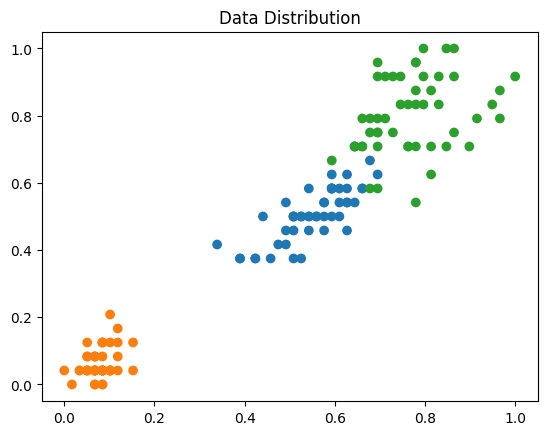

In [29]:
X, y = load_iris(return_X_y = True)

n_classes = len(set(y))

X = X[:, 2:]
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))     # 0-1 scaling
Y = jax.nn.one_hot(y, num_classes = n_classes)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

plt.scatter(X[:, 0], X[:, 1], c = y, cmap = cmap)
plt.title("Data Distribution")

### RBF Feature Map

In [30]:
KEY, rbf_key = random.split(KEY, 2)

x_min, x_max = X[:, 0].min(), X[:, 0].max()
y_min, y_max = X[:, 1].min(), X[:, 1].max()
center = 0.5 * jnp.array([x_max + x_min, y_max + y_min])
scale = jnp.array([x_max - x_min, y_max - y_min])

n_features = 100

centers = (jax.random.uniform(rbf_key, shape = (n_features, 2)) - 0.5) * scale + center

def rbf_phi(x, ell = 0.2):
    return jnp.exp(-0.5 * jnp.sum((x[:, None, :] - centers[None, :, :])**2 / ell**2, axis = -1))

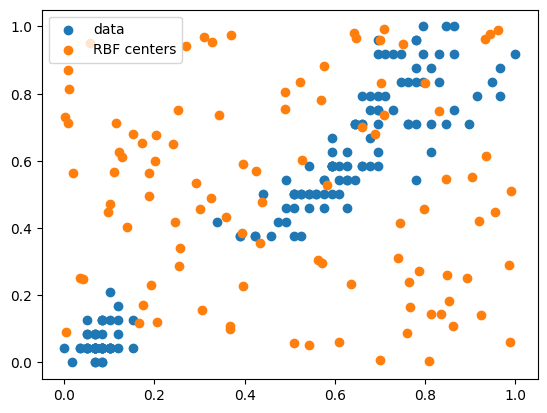

In [31]:
plt.scatter(X[:, 0], X[:, 1], label = "data")
plt.scatter(centers[:, 0], centers[:, 1], label = "RBF centers")
plt.legend()

### Prior

In [32]:
m = jnp.zeros(n_classes * n_features)
V = jnp.eye(n_classes * n_features)

prior = Gaussian(m, V)

### MAP Estimation

In [33]:
def multiclass_loss(X, Y, w, phi, prior):
    Phi = phi(X)
    logits = Phi @ w.reshape(Phi.shape[-1], Y.shape[-1])
    log_probs = jax.nn.log_softmax(logits, axis=1)
    
    return jnp.sum(Y * log_probs) + prior.log_pdf(w)

In [34]:
w = jnp.zeros(n_features * n_classes)
delta_norm = float("inf")

needed_iterations = 0

while delta_norm > 1e-3:

    L, g = jax.value_and_grad(multiclass_loss, argnums = 2)(X, Y, w, rbf_phi, prior)
    H = jax.hessian(multiclass_loss, argnums = 2)(X, Y, w, rbf_phi, prior)

    delta = jax.scipy.linalg.solve(H, g)
    delta_norm = jnp.linalg.norm(delta)

    w = w - delta

    needed_iterations += 1

print(f"converged in {needed_iterations} iterations")

converged in 7 iterations


In [35]:
W = w.reshape(n_features, n_classes)

logits = rbf_phi(X) @ W
probs = jax.nn.softmax(logits, axis=1)

y_pred = jnp.argmax(probs, axis=1)

print(f"MAP accuracy: {(y_pred == y).sum() / len(y_pred):.2%}")

MAP accuracy: 96.00%


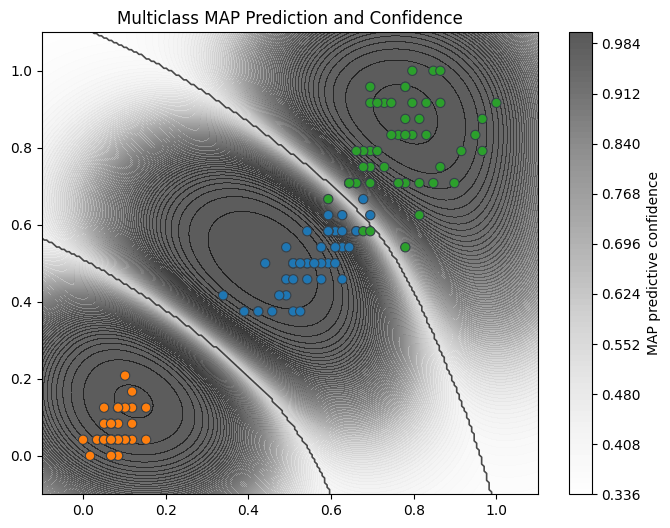

In [36]:
x1 = jnp.linspace(X[:, 0].min() - 0.1, X[:, 0].max() + 0.1, N)
x2 = jnp.linspace(X[:, 1].min() - 0.1, X[:, 1].max() + 0.1, N)
X1, X2 = jnp.meshgrid(x1, x2)
X_grid = jnp.stack((X1.flatten(), X2.flatten()), axis = 1)

logits = rbf_phi(X_grid) @ W
probs = jax.nn.softmax(logits, axis=1)

confidence = jnp.max(probs, axis=1)
predicted_class = jnp.argmax(probs, axis=1)

confidence_grid = confidence.reshape(X1.shape)
class_grid = predicted_class.reshape(X1.shape)

fig, ax = plt.subplots(figsize=(8, 6))

# MAP predictive confidence
contour = ax.contourf(
    X1,
    X2,
    confidence_grid,
    levels=100,
    cmap="Greys",
    vmin=1/3,
    vmax=1,
    alpha=0.65,
)

# Decision boundaries
ax.contour(
    X1,
    X2,
    class_grid,
    levels=[0.5, 1.5],
    colors="black",
    linewidths=1.2,
    alpha=0.7,
)

# Data
ax.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap=cmap,
    s=45,
    edgecolor=[0.21568627, 0.25490196, 0.29019608],
    linewidth=0.8,
    zorder=3,
)

fig.colorbar(contour, ax=ax, label="MAP predictive confidence")

ax.set_title("Multiclass MAP Prediction and Confidence")
plt.show()

## Predictive Distribution

In [37]:
KEY, normal_key = random.split(KEY, 2)
n_samples = 1_000

Sigma = -jax.scipy.linalg.inv(H)
L = jnp.linalg.cholesky(Sigma)

eps = random.normal(
    normal_key,
    shape=(n_samples, w.shape[0])
)

w_samples = w[None, :] + eps @ L.T

W_samples = w_samples.reshape(
    n_samples,
    n_features,
    n_classes
)

# Feature matrix on grid
Phi = rbf_phi(X_grid)       # (N_grid, n_features)

# logits_samples: (n_samples, N_grid, n_classes)
logits_samples = jnp.einsum(
    "nd,sdk->snk",
    Phi,
    W_samples
)

# Convert every sampled logit vector into class probabilities
prob_samples = jax.nn.softmax(
    logits_samples,
    axis=-1
)

# Monte Carlo posterior predictive
# shape: (N_grid, n_classes)
prob = prob_samples.mean(axis=0)

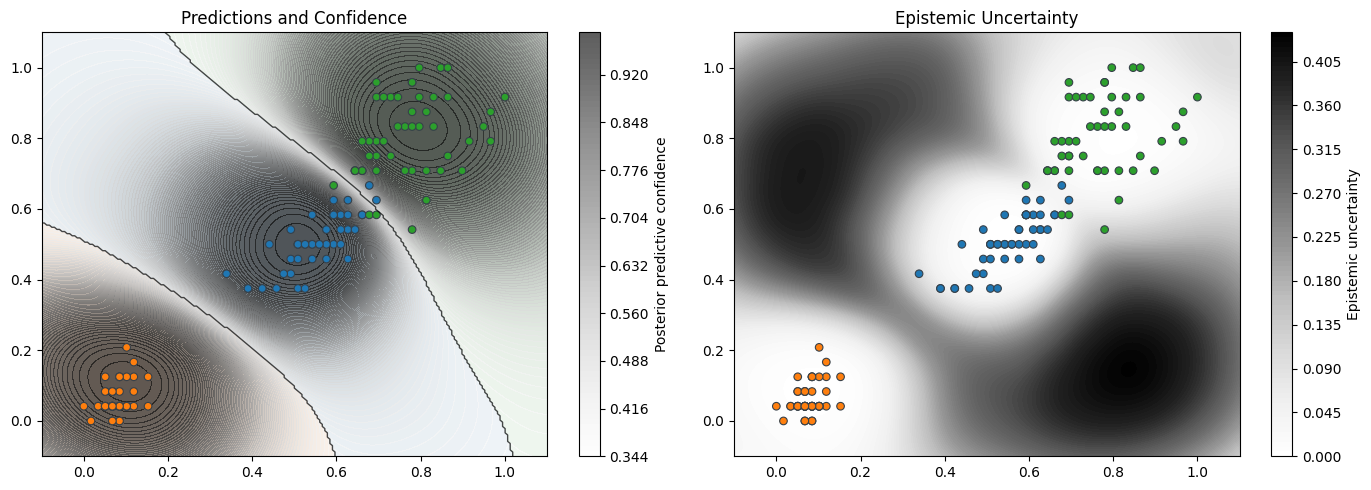

In [38]:
from matplotlib.colors import ListedColormap

class_cmap = ListedColormap(["#ff7f0e", "#1f77b4", "#2ca02c"])
n_classes = prob.shape[1]

predicted_class = jnp.argmax(prob, axis=1)                  # (N_grid,)
confidence = jnp.max(prob, axis=1)                          # (N_grid,)

# scalar epistemic uncertainty for multiclass:
# sum of per-class variances across posterior samples
epistemic = jnp.sum(jnp.var(prob_samples, axis=0), axis=1)  # (N_grid,)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# --------------------------------------------------
# 1) Predictions + confidence
# --------------------------------------------------

# soft class regions
ax[0].contourf(
    X1, X2,
    predicted_class.reshape(X1.shape),
    levels=jnp.arange(n_classes + 1) - 0.5,
    cmap=class_cmap,
    alpha=0.18,
)

# confidence background
conf_plot = ax[0].contourf(
    X1, X2,
    confidence.reshape(X1.shape),
    levels=100,
    cmap="Greys",
    alpha=0.65,
    vmin=1 / n_classes,
    vmax=1,
)

# decision boundaries
ax[0].contour(
    X1, X2,
    predicted_class.reshape(X1.shape),
    levels=jnp.arange(n_classes - 1) + 0.5,
    colors="black",
    linewidths=1.0,
    alpha=0.7,
)

# training data
ax[0].scatter(
    X[:, 0], X[:, 1],
    c=y,
    cmap=class_cmap,
    s=30,
    edgecolor=[0.21568627, 0.25490196, 0.29019608],
    linewidth=0.8,
)

fig.colorbar(conf_plot, ax=ax[0], label="Posterior predictive confidence")
ax[0].set_title("Predictions and Confidence")


# --------------------------------------------------
# 2) Epistemic uncertainty
# --------------------------------------------------

epi_plot = ax[1].contourf(
    X1, X2,
    epistemic.reshape(X1.shape),
    levels=100,
    cmap="Greys",
    alpha=1.0,
)

ax[1].scatter(
    X[:, 0], X[:, 1],
    c=y,
    cmap=class_cmap,
    s=30,
    edgecolor=[0.21568627, 0.25490196, 0.29019608],
    linewidth=0.8,
)

fig.colorbar(epi_plot, ax=ax[1], label="Epistemic uncertainty")
ax[1].set_title("Epistemic Uncertainty")

plt.tight_layout()
plt.show()

# Limitations


Laplace approximation assumes that the posterior can be approximated by a Gaussian around its mode. Thus, it may perform poorly for multimodal, asymmetric, or heavy-tailed posteriors.

The approximation also depends on the MAP estimate and on the chosen feature map. In our case, the behavior of the model strongly depends on the number, positions, and length scale of the RBF features.

Finally, computing and storing the full Hessian becomes expensive for large models, especially in the multiclass case. The posterior predictive distribution also requires an additional approximation, such as Monte Carlo sampling.

# Conclusion

In this notebook we introduced Bayesian logistic regression for binary and multiclass classification. Since the Gaussian prior is not conjugate to the Bernoulli or categorical likelihood, the posterior cannot be obtained in closed form.

We used the path

$$
\boxed{\text{MAP} \to \text{Laplace Approximation} \to \text{Monte Carlo}}
$$

to obtain an approximate posterior and posterior predictive distribution. This also allowed us to study predictive probabilities and epistemic uncertainty instead of using only a single MAP estimate.